In [ ]:
from __future__ import annotations
from pydantic import BaseModel, Field
from typing import Annotated, List, TypedDict
from langchain_core.messages import SystemMessage, HumanMessage

from langchain_ollama import ChatOllama

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
import operator

In [ ]:
#@ Pydantic Functions:

#Task:
class Task(BaseModel):
    id: int
    title: str
    brief: str= Field(..., description='What to look for')

#planner:
class Plan(BaseModel):
    blog_topic:str
    tasks:List[Task]

#state:
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add] #esults from workers get automatically concatenated
    final: str


In [ ]:
llm=ChatOllama(model="deepseek-r1:7b")

In [ ]:
#@ Orchestrator(Planner):
def orchestator(state:State)->dict:
    plan=llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=("Create a blog plan on 5-7 on the following topic")
            ),

            HumanMessage(content=f"topic:{state['topic']}")
        ]
    )

    return {plan: 'plan'}

- After the orchestrator node, system doesnt know how many workers do it need wrt to plan, so we need to built a fucntion which will trigger a worker for each plan/section

In [ ]:
def trigger(state: State):
    return [Send("Worker", {'task': task, 'topic': state['topic'], 'plan': state['plan']} )for task in state['plan'].tasks]


In [ ]:
#@ worker node:
def Worker(payload:dict):

    #payoad contains what we send
    task=payload['task']
    topic=payload['topic']
    plan=payload['plan']

    blog_topic=Plan.blog_topic

    section_md=llm.invoke(
        [
        SystemMessage(content="Write one clear markdown section"),
        HumanMessage(
            content=(
                f"Blog: {blog_topic}\n",
                f"topic: {topic}\n",
                f"section: {task.title}\n",
                f"brief: {task.brief}\n\n"
            )
        )]
    ).content.strip()

    return {"sections": [section_md]}

In [ ]:
from pathlib import Path

#@ Creating a reducer function:
def reducer(state:State):
    title=state['plan'].blog_topic
    body= "\n\n".join(state['sections']).strip()

    final_md=f'# {title} \n\n {body}\n'


    #@ Saving md files:
    filename=title.lower().replace('' '_') + ".md"
    output_path=Path(filename)
    output_path.write_text(final_md, encoding='utf-8')

    return {"final": final_md}


In [ ]:
g=StateGraph(State)
g.add_node("orchestator", orchestator)
g.add_node("worker", Worker)
g.add_node("reducer", reducer)

In [ ]:
g.add_edge(START, "orchestator")
g.add_conditional_edges("orchestator", trigger, ['worker'])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

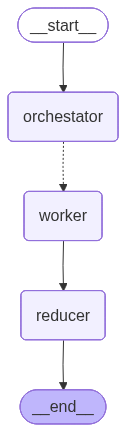

In [ ]:
app=g.compile()
app

In [ ]:
result=app.invoke({"topic": "write a blog on mountains", "sections":[]})

ResponseError: llama runner process has terminated: CUDA error (status code: 500)